In [1]:
import numpy as np
import pandas as pd
import random

In [5]:
def generate_normal_dataset(n=200, seed=42):
    np.random.seed(seed)
    random.seed(seed)

    data = []

    for i in range(n):
        workload_type = np.random.choice(["low", "medium", "high"])

        if workload_type == "low":
            cpu_avg = np.random.uniform(10, 30)
        elif workload_type == "medium":
            cpu_avg = np.random.uniform(30, 60)
        else:
            cpu_avg = np.random.uniform(60, 80)

        # Normal p95 behavior
        cpu_p95 = cpu_avg + np.random.uniform(5, 20)
        cpu_p95 = min(cpu_p95, 100)

        # Correlated memory
        memory_avg = cpu_avg + np.random.uniform(-10, 15)
        memory_avg = np.clip(memory_avg, 10, 90)

        # Semi-correlated network
        network_pct = cpu_avg + np.random.uniform(-20, 20)
        network_pct = np.clip(network_pct, 5, 90)

        # Mostly safe configurations
        internet_facing = np.random.choice([True, False], p=[0.3, 0.7])
        identity_attached = np.random.choice([True, False], p=[0.4, 0.6])

        data.append({
            "resource_id": f"r-{i}",
            "cpu_avg": round(cpu_avg, 2),
            "cpu_p95": round(cpu_p95, 2),
            "memory_avg": round(memory_avg, 2),
            "network_pct": round(network_pct, 2),
            "internet_facing": internet_facing,
            "identity_attached": identity_attached
        })

    return pd.DataFrame(data)

In [6]:
df = generate_normal_dataset(n=400)
df.head()

,resource_id,cpu_avg,cpu_p95,memory_avg,network_pct,internet_facing,identity_attached
0,r-0,75.93,83.68,85.42,79.80,False,True
1,r-1,77.32,91.34,85.03,58.15,False,False
2,r-2,30.02,49.91,35.46,34.49,True,True
3,r-3,72.24,79.33,69.54,66.89,False,False
4,r-4,67.65,87.40,69.32,82.05,False,False


In [7]:
df.describe()

,cpu_avg,cpu_p95,memory_avg,network_pct
count,400.000000,400.00000,400.000000,400.000000
mean,44.748975,57.30340,47.193250,44.383400
std,21.418812,22.07963,22.230103,22.640875
min,10.110000,16.11000,10.000000,5.000000
25%,24.672500,37.41500,27.757500,25.630000
50%,45.050000,58.04000,47.395000,45.950000
75%,64.970000,77.62750,65.892500,61.437500
max,79.730000,97.91000,90.000000,90.000000


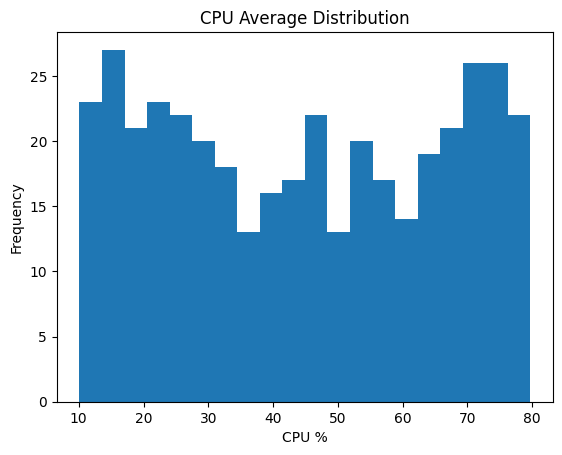

In [9]:
import matplotlib.pyplot as plt

plt.hist(df["cpu_avg"], bins=20)
plt.title("CPU Average Distribution")
plt.xlabel("CPU %")
plt.ylabel("Frequency")
plt.show()

In [10]:
df[["cpu_avg", "memory_avg", "network_pct"]].corr()

,cpu_avg,memory_avg,network_pct
cpu_avg,1.000000,0.943996,0.874546
memory_avg,0.943996,1.000000,0.822349
network_pct,0.874546,0.822349,1.000000


In [11]:
df.to_csv("normal_resources.csv", index=False)
print("Dataset saved as normal_resources.csv")

Dataset saved as normal_resources.csv


In [12]:
from dataclasses import dataclass

@dataclass
class ResourceMetrics:
    resource_id: str
    cpu_avg: float
    cpu_p95: float
    memory_avg: float
    network_pct: float
    internet_facing: bool
    identity_attached: bool

fleet = [
    ResourceMetrics(**row)
    for row in df.to_dict(orient="records")
]

len(fleet)

400

In [13]:
import pandas as pd
import numpy as np

def enhance_normal_dataset(input_file, output_file, seed=42):
    np.random.seed(seed)

    df = pd.read_csv(input_file)

    for i in range(len(df)):
        cpu = df.loc[i, "cpu_avg"]

        # --- 1. Add controlled noise to CPU ---
        cpu = cpu + np.random.normal(0, 3)
        cpu = np.clip(cpu, 10, 85)
        df.loc[i, "cpu_avg"] = round(cpu, 2)

        # --- 2. Reduce strong correlation (memory) ---
        memory = cpu + np.random.normal(0, 10)

        # occasional variation case (still normal)
        if np.random.rand() < 0.2:
            memory += np.random.uniform(5, 15)

        memory = np.clip(memory, 10, 90)
        df.loc[i, "memory_avg"] = round(memory, 2)

        # --- 3. Reduce strong correlation (network) ---
        network = cpu * np.random.uniform(0.5, 1.2) + np.random.normal(0, 12)

        # variation case: decouple from CPU
        if np.random.rand() < 0.25:
            network = np.random.uniform(15, 80)

        network = np.clip(network, 5, 90)
        df.loc[i, "network_pct"] = round(network, 2)

        # --- 4. Keep realistic p95 behavior ---
        cpu_p95 = cpu + np.random.uniform(5, 20)

        # occasional burst case
        if np.random.rand() < 0.15:
            cpu_p95 += np.random.uniform(10, 20)

        cpu_p95 = min(cpu_p95, 100)
        df.loc[i, "cpu_p95"] = round(cpu_p95, 2)

    df.to_csv(output_file, index=False)
    print(f"Enhanced dataset saved to {output_file}")


# Usage
enhance_normal_dataset("normal_resources.csv", "enhanced_normal_resources.csv")

Enhanced dataset saved to enhanced_normal_resources.csv
